# Project Title:

## "Understanding What Makes a Song a Hit"

### Business Context:

A record label wants to understand which characteristics of songs are associated with higher audience engagement and popularity across streaming platforms.

The analysis explores how musical attributes (such as danceability, energy, tempo, and acousticness) and audience engagement metrics (likes, views, comments) relate to streaming performance.

### Problem Definition & Objective

Key Question:

What characteristics of songs are associated with the highest streaming performance and audience engagement?

Business Importance:

For a music label, identifying the attributes linked to successful songs can help:

- Guide artist production decisions
- Inform marketing strategies
- Improve playlist and promotion targeting
- Increase the probability of producing commercially successful tracks
- 
Objectives:

This project aims to:

- Identify which song features correlate with higher streams and views
- Examine how engagement metrics (likes, comments) relate to streaming success
- Determine whether certain musical attributes are more common in high-performing tracks

Hypotheses:

We will test ideas such as:

- Songs with higher danceability and energy receive more streams.
- Tracks with higher audience engagement (likes/comments) also achieve higher streaming counts.
- Certain tempo ranges or valence levels are more common among top-performing songs.

### Data Collection & Cleaning

Data Source:

The dataset used in this analysis is a public Spotify music dataset, containing information on song characteristics and engagement metrics across streaming platforms. This was imported from: https://www.gigasheet.com/sample-data/spotify-dataset

Type of Data:

The dataset includes several categories of variables:

- Audio Features
- Danceability
- Energy
- Tempo
- Loudness
- Acousticness
- Instrumentalness
- Valence
- Speechiness
- Engagement Metrics
- Views
- Likes
- Comments
- Streaming Metrics
- Streams
- Song Metadata
- Artist
- Track name
- Album type
- Tools Used

Data preparation and analysis were conducted using:

- Python
- Pandas for data manipulation
- NumPy for numerical operations
- Matplotlib & Seaborn for data visualisation
- Jupyter Notebook for analysis and documentation

Planned Cleaning Steps:

Before analysis we will:

- Inspect the dataset structure
- Check for missing values
- Identify duplicate records
- Convert numeric fields to proper formats
- Examine outliers and inconsistent values

In [21]:
# Data manipulation

import pandas as pd
import numpy as np

# Visualisation

import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer

sns.set_style("whitegrid")

In [22]:
# Load dataset
df = pd.read_csv("data/spotify_dataset.csv")

# Show first rows
df.head()

,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221,6220896,169907,True,True,1040234854,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645,1079128,31003,True,True,310083733,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055,282142,7399,True,True,63063467,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952,1788577,55229,True,True,434663559,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958,6197318,155930,True,True,617259738,9.942693,Youtube


In [23]:
# Check dataset structure
df.shape

(20594, 24)

In [24]:
df.columns

Index(['Artist', 'Track', 'Album', 'Album_type', 'Danceability', 'Energy',
       'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Duration_min', 'Title', 'Channel',
       'Views', 'Likes', 'Comments', 'Licensed', 'official_video', 'Stream',
       'EnergyLiveness', 'most_playedon'],
      dtype='object')

In [25]:
# Basic dataset overview

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20594 entries, 0 to 20593
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            20594 non-null  object 
 1   Track             20594 non-null  object 
 2   Album             20594 non-null  object 
 3   Album_type        20594 non-null  object 
 4   Danceability      20594 non-null  float64
 5   Energy            20594 non-null  float64
 6   Loudness          20594 non-null  float64
 7   Speechiness       20594 non-null  float64
 8   Acousticness      20594 non-null  float64
 9   Instrumentalness  20594 non-null  float64
 10  Liveness          20594 non-null  float64
 11  Valence           20594 non-null  float64
 12  Tempo             20594 non-null  float64
 13  Duration_min      20594 non-null  float64
 14  Title             20594 non-null  object 
 15  Channel           20594 non-null  object 
 16  Views             20594 non-null  int64 

In [26]:
# Summary statistics

df.describe()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_min,Views,Likes,Comments,Stream,EnergyLiveness
count,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,2.059400e+04,2.059400e+04,2.059400e+04,2.059400e+04,20594.000000
mean,0.620102,0.635176,-7.678254,0.096733,0.291391,0.056162,0.193653,0.530077,120.562616,3.742439,9.203740e+07,6.479902e+05,2.684679e+04,1.326446e+08,5.166725
std,0.165504,0.214274,4.639481,0.112182,0.286117,0.193622,0.168832,0.245542,29.588093,2.085211,2.726026e+08,1.773648e+06,1.911751e+05,2.423582e+08,4.117546
min,0.000000,0.000000,-46.251000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,0.519000,0.507000,-8.868000,0.035700,0.045200,0.000000,0.094100,0.340000,96.994000,2.996746,1.478284e+06,1.754200e+04,4.060000e+02,1.559098e+07,2.386139
50%,0.638000,0.666000,-6.540500,0.050650,0.193000,0.000002,0.125000,0.538000,119.959000,3.551267,1.331348e+07,1.153155e+05,3.006000e+03,4.730525e+07,4.256783
75%,0.741000,0.798000,-4.935000,0.104000,0.476750,0.000474,0.237000,0.727000,139.923500,4.202163,6.739682e+07,5.000198e+05,1.373675e+04,1.343453e+08,6.821846
max,0.975000,1.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,77.934300,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09,59.113924


In [27]:
# Check missing values

df.isnull().sum()

Artist              0
Track               0
Album               0
Album_type          0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_min        0
Title               0
Channel             0
Views               0
Likes               0
Comments            0
Licensed            0
official_video      0
Stream              0
EnergyLiveness      0
most_playedon       0
dtype: int64

### Exploratory Data Analysis (EDA)

Initial Exploration:

To understand the dataset, an exploratory analysis was conducted to examine the distribution of song performance metrics and audio characteristics.

The analysis focused primarily on Streams as the main indicator of song success, while also considering engagement metrics such as Views, Likes, and Comments.

The goal of this stage was to:

- Understand the distribution of song popularity
- Identify high-performing songs (hits)
- Explore relationships between musical features and success

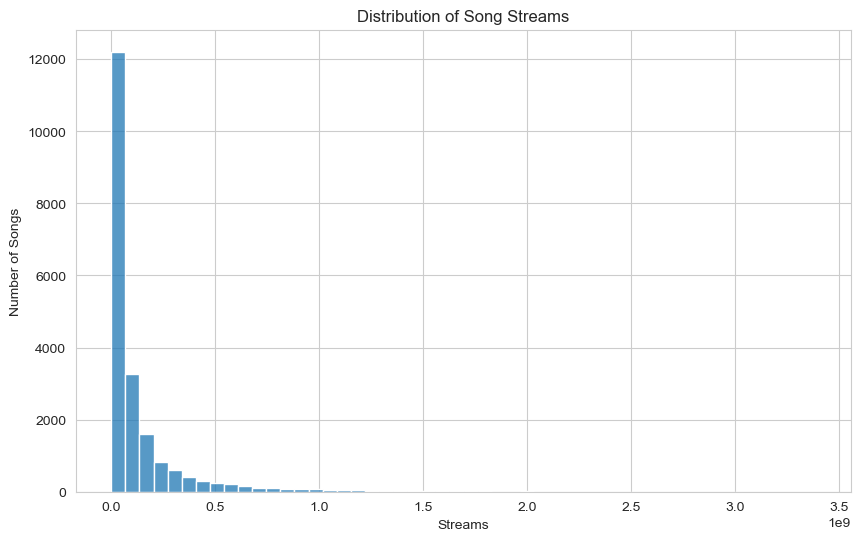

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(df["Stream"], bins=50)
plt.title("Distribution of Song Streams")
plt.xlabel("Streams")
plt.ylabel("Number of Songs")
plt.show()

# This shows whether most songs perform similarly or if a small number dominate the streams (which is common in music).

### Distribution of Streams

The distribution of streams is highly right-skewed, indicating that most songs receive relatively low streaming counts while a small number of tracks accumulate extremely high numbers of streams.

This pattern is common in the music industry, where a small number of major hits dominate overall listening activity. The observation supports the decision to classify songs into “Hit” and “Non-Hit” categories based on the top percentile of streaming performance.

In [31]:
# Identiying the biggest hits

df.sort_values(by="Stream", ascending=False).head(10)

,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
15166,The Weeknd,Blinding Lights,After Hours,album,0.514,0.730,-5.934,0.0598,0.00146,0.000095,...,The Weeknd - Blinding Lights (Official Video),TheWeekndVEVO,674164500,8817927,282589,True,True,3386520288,8.138239,Spotify
12385,Ed Sheeran,Shape of You,÷ (Deluxe),album,0.825,0.652,-3.183,0.0802,0.58100,0.000000,...,Ed Sheeran - Shape of You (Official Music Video),Ed Sheeran,5908398479,31047780,1130327,True,True,3362005201,7.003222,Youtube
19082,Lewis Capaldi,Someone You Loved,Divinely Uninspired To A Hellish Extent,album,0.501,0.405,-5.679,0.0319,0.75100,0.000000,...,Lewis Capaldi - Someone You Loved,LewisCapaldiVEVO,586768373,7367091,147565,True,True,2634013335,3.857143,Spotify
17847,Post Malone,rockstar (feat. 21 Savage),beerbongs & bentleys,album,0.585,0.520,-6.136,0.0712,0.12400,0.000070,...,Post Malone ft. 21 Savage - rockstar (Official...,PostMaloneVEVO,1060220169,12564657,366520,True,True,2594926619,3.969466,Spotify
17356,Swae Lee,Sunflower - Spider-Man: Into the Spider-Verse,Hollywood's Bleeding,album,0.755,0.522,-4.368,0.0575,0.53300,0.000000,...,"Post Malone, Swae Lee - Sunflower (Spider-Man:...",PostMaloneVEVO,1977389027,13749806,331064,True,True,2538329799,7.620438,Spotify
17848,Post Malone,Sunflower - Spider-Man: Into the Spider-Verse,Hollywood's Bleeding,album,0.755,0.522,-4.368,0.0575,0.53300,0.000000,...,"Post Malone, Swae Lee - Sunflower (Spider-Man:...",PostMaloneVEVO,1977389041,13749813,331063,True,True,2538329799,7.620438,Spotify
13433,Drake,One Dance,Views,album,0.792,0.625,-5.609,0.0536,0.00776,0.001800,...,Drake - One Dance (Lyrics) ft. Wizkid & Kyla,Billion Stars,169288294,1662640,13775,False,False,2522431995,1.899696,Spotify
15939,Halsey,Closer,Closer,single,0.748,0.524,-5.599,0.0338,0.41400,0.000000,...,The Chainsmokers - Closer (Official Video) ft....,ChainsmokersVEVO,455914466,3423268,93021,True,True,2456205158,4.720721,Spotify
16010,The Chainsmokers,Closer,Closer,single,0.748,0.524,-5.599,0.0338,0.41400,0.000000,...,The Chainsmokers - Closer (Official Video) ft....,ChainsmokersVEVO,455914466,3423268,93021,True,True,2456205158,4.720721,Spotify
13960,Imagine Dragons,Believer,Evolve,album,0.776,0.780,-4.374,0.1280,0.06220,0.000000,...,Imagine Dragons - Believer (Official Music Video),ImagineDragonsVEVO,2369714846,20483444,613230,True,True,2369272335,9.629630,Youtube


In [32]:
# Creating a "Hit Song" category

# Define hit threshold
hit_threshold = df["Stream"].quantile(0.90)

# Create hit column
df["Hit"] = df["Stream"] >= hit_threshold

df["Hit"].value_counts()

Hit
False    18534
True      2060
Name: count, dtype: int64

### Hit Definition

To analyse what drives song success, tracks were categorised as “Hit” songs if they fell within the top 10% of streams in the dataset.

This threshold allows comparison between high-performing tracks and the rest of the catalogue, helping identify features associated with successful songs.

In [33]:
# Comparing Hit vs Non-Hit Song Characteristics

hit_comparison = df.groupby("Hit")[[
    "Danceability",
    "Energy",
    "Valence",
    "Acousticness",
    "Instrumentalness",
    "Tempo"
]].mean()

hit_comparison

,Danceability,Energy,Valence,Acousticness,Instrumentalness,Tempo
Hit,,,,,,
False,0.616312,0.632171,0.530949,0.301032,0.060884,120.558021
True,0.654202,0.662214,0.522232,0.204651,0.013674,120.603961


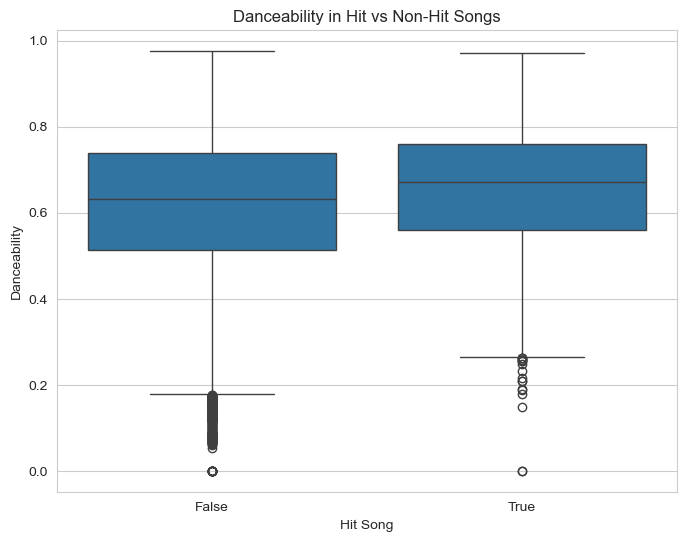

In [34]:
# Danceability vs Hits

plt.figure(figsize=(8,6))
sns.boxplot(x="Hit", y="Danceability", data=df)

plt.title("Danceability in Hit vs Non-Hit Songs")
plt.xlabel("Hit Song")
plt.ylabel("Danceability")

plt.show()

### Feature Comparison


To understand which musical characteristics are associated with successful songs, audio features were compared between hit songs and non-hit songs.

Boxplots and summary statistics were used to identify differences in variables such as danceability, energy, and tempo.

### Preliminary Feature Insights


Initial comparisons between hit and non-hit songs revealed small but notable differences in musical attributes.

Hit songs showed slightly higher danceability, suggesting that more rhythmically engaging tracks may perform better with audiences. However, the difference was relatively small.

A more pronounced difference appeared in instrumentalness. Hit songs had substantially lower instrumentalness values, indicating that songs with vocals and lyrical content are far more likely to achieve high streaming performance compared to instrumental tracks.

This aligns with common industry patterns, where vocal-driven songs dominate mainstream popularity.

In [36]:
# Select numerical variables
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation with Streams
stream_corr = numeric_df.corr()["Stream"].sort_values(ascending=False)

stream_corr

Stream              1.000000
Likes               0.646946
Views               0.596022
Comments            0.266147
Loudness            0.120238
Danceability        0.073570
Energy              0.042948
EnergyLiveness      0.041753
Tempo               0.002985
Duration_min       -0.011151
Valence            -0.013309
Speechiness        -0.021778
Liveness           -0.041064
Instrumentalness   -0.091950
Acousticness       -0.102319
Name: Stream, dtype: float64

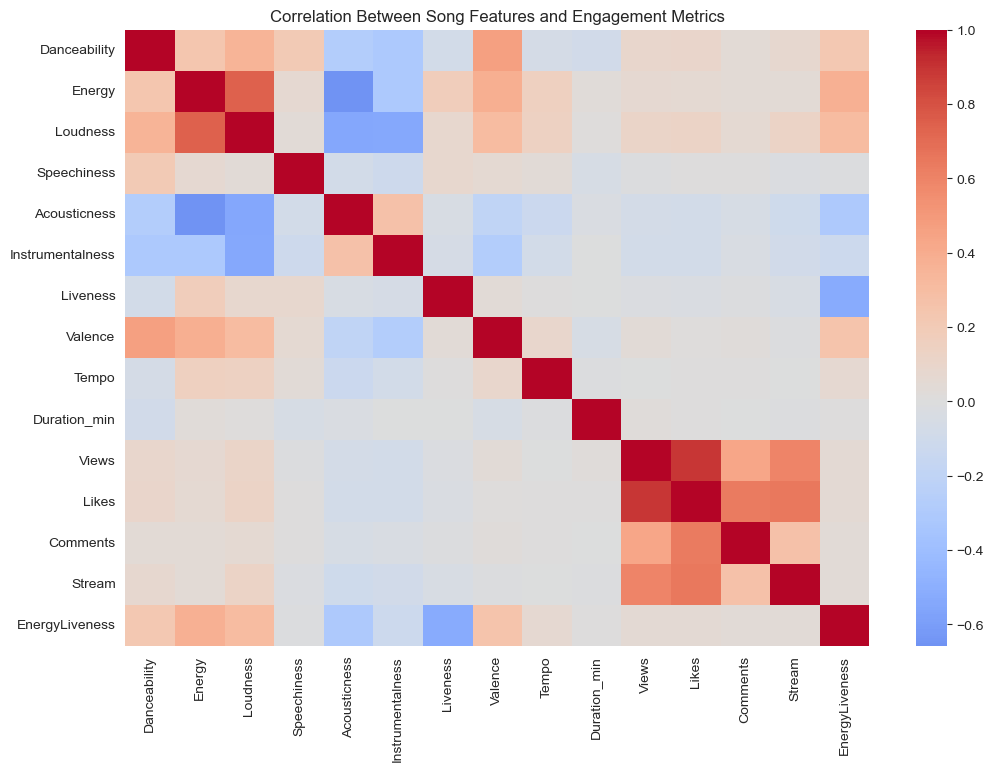

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)

plt.title("Correlation Between Song Features and Engagement Metrics")
plt.show()

### Correlation with Streaming Performance

Correlation analysis was used to identify which variables were most strongly associated with streaming success.
The strongest relationships with streams were observed in engagement metrics, particularly:
- Likes
- Views
- Comments

These results suggest that songs generating higher audience interaction also achieve greater streaming performance.

Musical characteristics such as danceability, energy, and tempo showed relatively weak correlations with streams. This indicates that while these attributes may influence listener preferences, they alone do not strongly determine commercial success.

Interestingly, instrumentalness and acousticness showed negative correlations, suggesting that tracks with more prominent vocals and production elements may perform better in streaming environments.

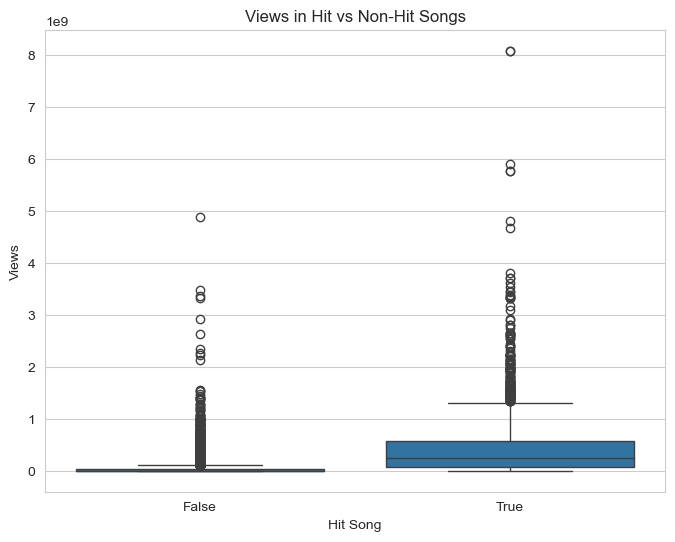

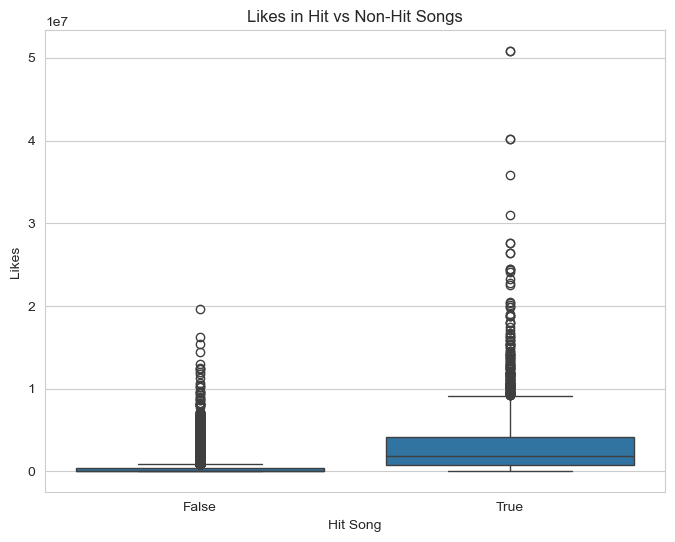

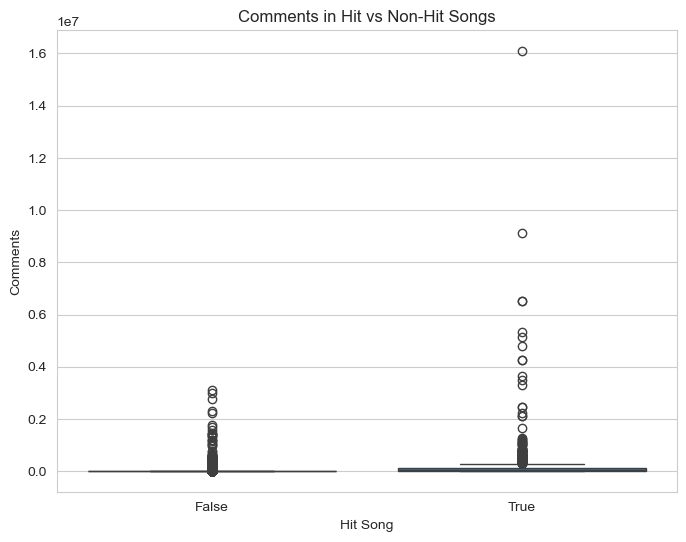

In [38]:
engagement_features = ["Views", "Likes", "Comments"]

for feature in engagement_features:
    
    plt.figure(figsize=(8,6))
    sns.boxplot(x="Hit", y=feature, data=df)
    
    plt.title(f"{feature} in Hit vs Non-Hit Songs")
    plt.xlabel("Hit Song")
    plt.ylabel(feature)
    
    plt.show()

### Engagement Analysis

Visual comparisons between hit and non-hit songs show substantial differences in engagement metrics such as views, likes, and comments. 

Hit songs consistently demonstrate higher audience interaction, reinforcing the strong correlation observed between engagement indicators and streaming performance.

In [39]:
# Log transform engagement metrics to reduce extreme skew
df["log_views"] = np.log1p(df["Views"])
df["log_likes"] = np.log1p(df["Likes"])
df["log_comments"] = np.log1p(df["Comments"])

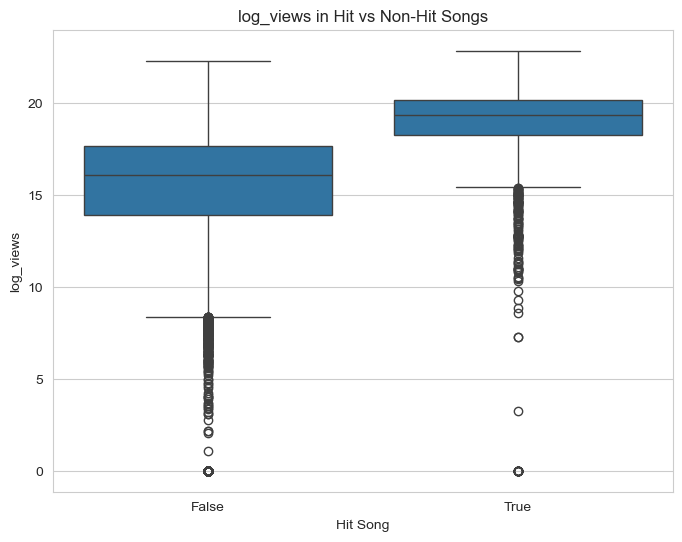

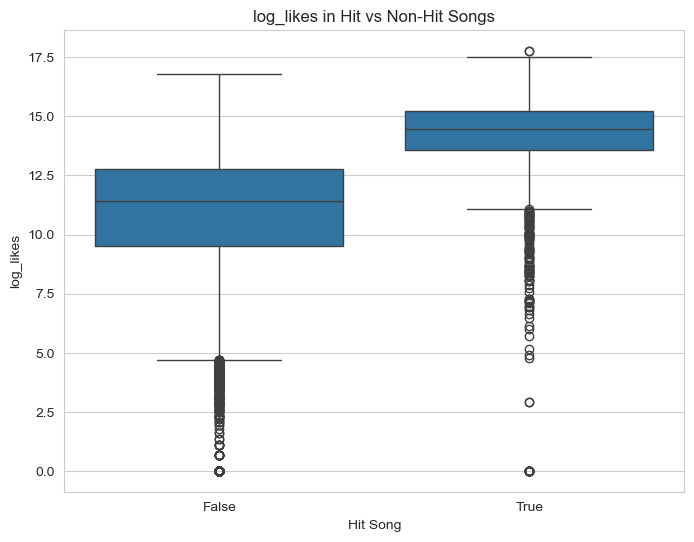

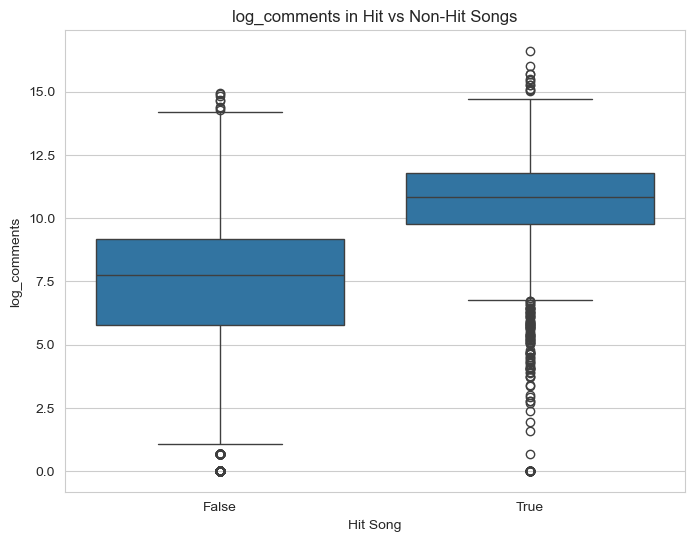

In [40]:
engagement_features = ["log_views", "log_likes", "log_comments"]

for feature in engagement_features:

    plt.figure(figsize=(8,6))
    sns.boxplot(x="Hit", y=feature, data=df)

    plt.title(f"{feature} in Hit vs Non-Hit Songs")
    plt.xlabel("Hit Song")
    plt.ylabel(feature)

    plt.show()

### Handling Extreme Values in Engagement Metrics

Engagement metrics such as views, likes, and comments showed extremely skewed distributions due to a small number of globally popular songs.

These outliers compressed the majority of observations in visualisations.

To improve interpretability, a logarithmic transformation was applied to engagement variables. This transformation reduces the influence of extreme values while preserving the relative differences between songs, allowing clearer comparison between hit and non-hit tracks.

In [62]:
# Comparing Feature Avarages

feature_comparison = df.groupby("Hit")[[
    "Danceability",
    "Energy",
    "Loudness",
    "Acousticness",
    "Instrumentalness",
    "Tempo",
    "Valence"
]].mean()

feature_comparison

,Danceability,Energy,Loudness,Acousticness,Instrumentalness,Tempo,Valence
Hit,,,,,,,
False,0.616312,0.632171,-7.825080,0.301032,0.060884,120.558021,0.530949
True,0.654202,0.662214,-6.357242,0.204651,0.013674,120.603961,0.522232


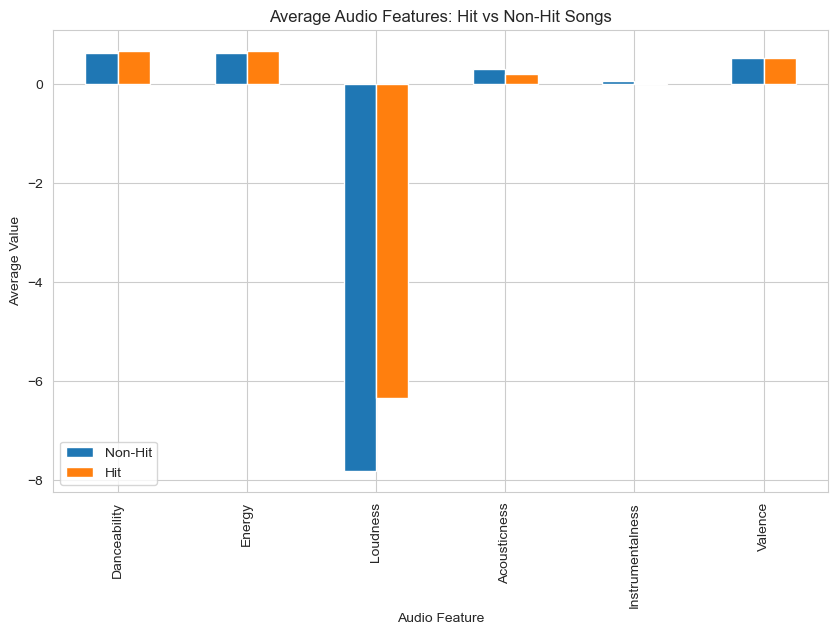

In [64]:
features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Acousticness",
    "Instrumentalness",
    "Valence"
]

feature_comparison = df.groupby("Hit")[features].mean()

feature_comparison.T.plot(kind="bar", figsize=(10,6))

plt.title("Average Audio Features: Hit vs Non-Hit Songs")
plt.ylabel("Average Value")
plt.xlabel("Audio Feature")
plt.legend(["Non-Hit", "Hit"])

plt.show()

### Comparison of Audio Features

Comparing the average audio characteristics of hit and non-hit songs revealed several notable differences.

Hit songs tended to have lower instrumentalness, indicating that tracks with vocals are significantly more likely to achieve high streaming success. Additionally, hit songs showed slightly higher danceability and loudness, suggesting that rhythmically engaging and strongly produced tracks may perform better with listeners.

However, the differences across most audio features were relatively modest. This suggests that musical attributes alone do not fully determine commercial success, and that other factors—such as marketing, artist popularity, and audience engagement—likely play a significant role.

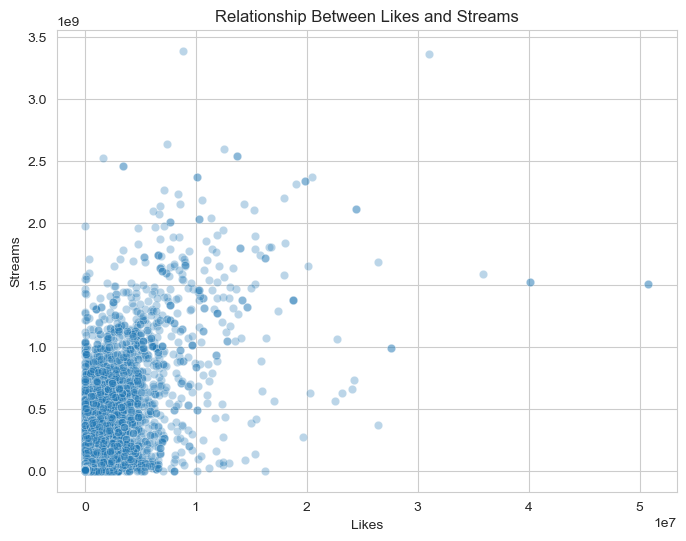

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="Likes", y="Stream", data=df, alpha=0.3)

plt.title("Relationship Between Likes and Streams")
plt.xlabel("Likes")
plt.ylabel("Streams")

plt.show()

### Relationship Between Engagement and Streaming Performance

A scatter plot was used to examine the relationship between likes and streams. The results indicate a clear positive relationship: songs that receive more audience engagement tend to accumulate higher streaming counts.

Although the distribution contains significant variability—reflecting the complex nature of music consumption—the overall trend suggests that **audience interaction metrics such as likes and comments can serve as useful indicators of a song’s popularity.**

This finding is consistent with the earlier correlation analysis, which showed a relatively strong relationship between engagement metrics and streaming performance.

### Key Insights for a Record Label

• Streaming success is **highly concentrated** in a small number of songs.

• **Audience engagement (likes, views, comments)** is strongly associated with streaming performance.

• Hit songs tend to have **lower instrumentalness**, indicating that vocal-driven tracks dominate popular listening.

• Musical attributes such as **danceability and loudness** show small positive differences in hit songs.

• Audio features alone do not fully explain success, suggesting that **external factors like promotion, artist recognition, and playlist placement likely play major roles.**